# Stochastic two-dimensional potential game

Install the package using the [project README](../../README.md), then run the cells in order. Results are saved under `results/potential_game_2d_stochastic_mmnn/`.

This extends the two-player potential game to
\[
dX_t=b(X_t)\,dt+\sigma\,dW_t,\qquad \sigma=0.1,\quad b=\nabla\Phi.
\]
Here **0.1 is the Brownian noise amplitude**. The covariance is $0.01I_2$,
and the Fokker–Planck diffusion coefficient is $\sigma^2/2=0.005$.

The MMNN DTB particles follow a probability-flow velocity with a transported
density score. An Euler–Maruyama ensemble supplies the stochastic reference.
The notebook reuses the package's stochastic velocity correction, tangent,
SVD, spatial derivative, score transport, sampling, reference-integration,
and plotting functions. The game
definition and loop remain in this notebook.


In [ ]:
from pathlib import Path
import json
import os
import shutil
import socket
import sys
import time

import dtb_game

# Locate this project for numerical output.
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / 'pyproject.toml').is_file() and (path / 'src' / 'dtb_game').is_dir()),
    None,
)
if repo_root is None:
    raise FileNotFoundError('Open this notebook from the project checkout.')

import_root = Path(dtb_game.__file__).resolve().parent
source_sha256 = None
results_root = repo_root / 'results'

import matplotlib.pyplot as plt
import numpy as np
import torch
from dtb_game.dynamics import (FunctionalGame, ConstantDiffusion)
from dtb_game.models import (ResidualMMNN, count_parameters)
from dtb_game.integrators import (dtb_step, advance_score)
from dtb_game.projection import (evaluate_dtb_projection, evaluate_model, flat_parameters, subset_tangent_selection, tangent_spatial_terms, TangentProjection)
from dtb_game.experiment import (ExperimentConfig, _probability_flow_correction)
from dtb_game.integrators import (_advance_reference)
from dtb_game.utils import (make_time_grid, resolve_device, resolve_dtype, sample_uniform_box, sample_initial_with_score, snapshot_indices, sliced_wasserstein_distance, to_numpy, warmup_cuda, write_csv, write_json)
from dtb_game.plotting import (plot_cloud_snapshots, plot_diagnostics, plot_stochastic_diagnostics)

print("Host:", socket.gethostname())
print("Python:", sys.executable)
print("Working directory:", Path.cwd())
print("Package source:", import_root)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("Results base directory:", results_root)


## Drift, probability flow, and score

The potential and drift retain the deterministic example's parameters:
\[
\Phi(x)=-\frac{\lambda}{2}(x_1^2+x_2^2)-\frac{\gamma}{2}(x_1-x_2)^2
+\frac{\epsilon}{\omega}\bigl[\cos(\omega x_1)+\cos(\omega x_2)\bigr],
\qquad (\lambda,\gamma,\epsilon,\omega)=(0.5,0.2,0.5,4\pi).
\]
With the score $q_t(x)=\nabla_x\log\rho_t(x)$, the probability-flow target is
\[
g_t(x)=b(x)-\frac{\sigma^2}{2}q_t(x)=b(x)-0.005q_t(x).
\]
Diffusion enters the DTB update through this score correction. Euler–Maruyama
uses the Brownian increment $\sigma\sqrt{\Delta t}\,\xi$.

The stochastic implementation already exists in the supplied bundle:
`ConstantDiffusion.isotropic` specifies the noise;
`experiment._probability_flow_correction` computes
$\tfrac12[\nabla\cdot a+a q]$, where $a=\Sigma\Sigma^T$; and
`dtb.tangent_spatial_terms` with `dtb.advance_score` evolves the score.
The notebook calls these same functions used by `run_experiment` with
`dynamics="stochastic"`, while keeping the requested game definition and
time loop here. The underscore-prefixed correction and reference helpers
are internal APIs of this supplied bundle.

For a smooth initial score, the default law is a slightly smoothed box:
$X_0=U+\eta Z$, with $U\sim U([-1,1]^2)$, $Z\sim N(0,I_2)$, and $\eta=0.1$.
The package supplies its analytic score. `SMOOTHING_STD` controls this initial
smoothing separately from the SDE noise amplitude. A Gaussian initial law is
also available. A hard uniform density has a singular boundary score, so it
is not used for score initialization.

The SDE is evolved on $\mathbb{R}^2$ with the confining potential drift.
The box describes the unsmoothed initial support; no reflecting boundary or
clipping is imposed. Fractions outside the box are recorded for both ensembles.


In [2]:
DIM = 2
LAMBDA, GAMMA, EPSILON, OMEGA = 0.5, 0.2, 0.5, 4 * np.pi
SEED = 2026
N_PARTICLES = 200
DIFFUSION_AMPLITUDE = 0.1  # sigma in dX = b(X) dt + sigma dW
INITIAL_LAW = "smoothed_uniform"  # or "gaussian"
SMOOTHING_STD = 0.1
GAUSSIAN_MEAN, GAUSSIAN_STD = 0.0, 0.5
REFERENCE_SEED = SEED + 2
SW_PROJECTIONS = 128
SW_SEED = SEED + 3
H = 0.005
T_FINAL = 1.0
SNAPSHOT_TIMES = (0.0, 0.25, 0.5, 0.75, 1.0)

MMNN_WIDTH, MMNN_RANK, MMNN_DEPTH = 12, 12, 3
ACTIVATION = "tanh"
TANGENT_BASIS_SIZE = None  # full basis, or an integer >= DIM
SUBSET_MODE = "fixed"     # "fixed" or "resample_each_step"
SVD_RTOL = 1e-5
JACOBIAN_CHUNK = 1024
SCORE_CHUNK = 1024
DTYPE = "float64"
DEVICE = "auto"           # CUDA if available, otherwise CPU
CPU_THREADS = max(1, min(4, int(os.environ.get("SLURM_CPUS_PER_TASK", "4"))))
REFERENCE_MAX_STEP = H / 4
OUTPUT_ROOT = results_root / "potential_game_2d_stochastic_mmnn"  # or an absolute project-storage path


def velocity(x, t=0.0):
    """Gradient ascent for one joint strategy per row: shape (N, 2)."""
    return (-LAMBDA * x
            - GAMMA * (DIM * x - x.sum(dim=-1, keepdim=True))
            - EPSILON * torch.sin(OMEGA * x))


def potential(x):
    # sum_{i<j}(x_i-x_j)^2 = DIM * sum_i(x_i - mean(x))^2
    pairwise_sum = DIM * (x - x.mean(dim=-1, keepdim=True)).square().sum(dim=-1)
    return (-0.5 * LAMBDA * x.square().sum(dim=-1)
            - 0.5 * GAMMA * pairwise_sum
            + (EPSILON / OMEGA) * torch.cos(OMEGA * x).sum(dim=-1))


# Notebook-local callable; no new class or configuration in games.py.
game = FunctionalGame(dim=DIM, name="potential_game_2d_stochastic", velocity_fn=velocity)
diffusion = ConstantDiffusion.isotropic(DIM, amplitude=DIFFUSION_AMPLITUDE)
diffusion_coefficient = 0.5 * DIFFUSION_AMPLITUDE**2
# Reuse the bundle's Euler–Maruyama substepping helper.
reference_config = ExperimentConfig(
    dynamics="stochastic", reference_integrator="euler_maruyama",
    reference_step_size=REFERENCE_MAX_STEP,
)

# Independent check of the sign and all-to-all coupling against the potential.
check_x = sample_uniform_box(7, DIM, low=-1, high=1, dtype=torch.float64,
                             device=torch.device("cpu"), seed=SEED + 9)
check_x.requires_grad_(True)
check_gradient = torch.autograd.grad(potential(check_x).sum(), check_x)[0]
torch.testing.assert_close(velocity(check_x), check_gradient, rtol=1e-12, atol=1e-12)
print("Velocity agrees with grad(Phi).")


Velocity agrees with grad(Phi).


## DTB loop and score transport

At each step the tangent is evaluated at the **current physical particles**:
$J_k=\partial_{\theta_{S_k}}T_{\theta_k}(X_k)$.
This choice lets `tangent_spatial_terms` differentiate the physical velocity
field with respect to $x$. Fixed initial labels remain useful for identifying
particles, but are not passed as tangent inputs in this stochastic loop.

1. Evaluate $g_k=b(X_k)-\tfrac12\sigma^2q_k$ and solve
   $\alpha_k=\arg\min_\alpha\|J_k\alpha-g_k\|_2^2$ by truncated SVD.
2. Define $u_k(x)=\partial_{\theta_{S_k}}T_{\theta_k}(x)\alpha_k$ and advance
   $X_{k+1}=X_k+h u_k(X_k)$ and $\theta_{k+1,S_k}=\theta_{k,S_k}+h\alpha_k$.
3. Using the same **pre-update** parameters, particles, and coefficients,
   advance the score of the transported density:
   \[
   q_{k+1}=q_k-h\left[(D_xu_k(X_k))^Tq_k+\nabla_x\operatorname{div}u_k(X_k)\right].
   \]

The score update is the package's explicit-Euler discretization of the
continuous score-transport equation. It approximates the score of the DTB
density; finite steps and projection error affect its accuracy. MMNN uses
smooth `tanh` features for these spatial derivatives. There is no reset/refit.
SVD failures use the tested NumPy backend fallback, with the same cutoff and
normalization. The package handles every normal projection.


In [3]:
if DIM != 2:
    raise ValueError("This notebook is the two-player example: DIM must be 2.")
if SUBSET_MODE not in {"fixed", "resample_each_step"}:
    raise ValueError("SUBSET_MODE must be fixed or resample_each_step.")
if not 0 <= SVD_RTOL < 1 or JACOBIAN_CHUNK < 1 or CPU_THREADS < 1:
    raise ValueError("Invalid SVD tolerance, Jacobian chunk, or CPU thread count.")
if not np.isfinite(REFERENCE_MAX_STEP) or REFERENCE_MAX_STEP <= 0:
    raise ValueError("REFERENCE_MAX_STEP must be positive and finite.")
if INITIAL_LAW not in {"smoothed_uniform", "gaussian"}:
    raise ValueError("Use smoothed_uniform or gaussian for a well-defined initial score.")
if ACTIVATION not in {"tanh", "sin", "gelu"}:
    raise ValueError("Score transport requires a smooth MMNN activation.")
if not np.isfinite(DIFFUSION_AMPLITUDE) or DIFFUSION_AMPLITUDE < 0:
    raise ValueError("DIFFUSION_AMPLITUDE must be finite and nonnegative.")
if SCORE_CHUNK < 1 or SW_PROJECTIONS < 1:
    raise ValueError("SCORE_CHUNK and SW_PROJECTIONS must be positive.")
device, dtype = resolve_device(DEVICE), resolve_dtype(DTYPE)
torch.set_num_threads(CPU_THREADS)
torch.manual_seed(SEED)
warmup_cuda(device, dtype)
z, initial_score = sample_initial_with_score(
    N_PARTICLES, DIM, law=INITIAL_LAW, smoothing_std=SMOOTHING_STD,
    gaussian_mean=GAUSSIAN_MEAN, gaussian_std=GAUSSIAN_STD,
    uniform_low=-1.0, uniform_high=1.0, dtype=dtype, device=device,
    generator=torch.Generator().manual_seed(SEED),
)
if not torch.isfinite(z).all() or not torch.isfinite(initial_score).all():
    raise FloatingPointError("Initial particles or scores are nonfinite.")
model = ResidualMMNN(DIM, width=MMNN_WIDTH, rank=MMNN_RANK,
                     depth=MMNN_DEPTH, activation=ACTIVATION,
                     dtype=dtype, zero_init_output=True).to(device)
theta, structure = flat_parameters(model)
initial_theta = theta.clone()
torch.testing.assert_close(evaluate_model(theta, z, model, structure), z, rtol=0, atol=0)
parameter_count = count_parameters(model)
m = parameter_count if TANGENT_BASIS_SIZE is None else TANGENT_BASIS_SIZE
if not isinstance(m, int) or isinstance(m, bool) or not DIM <= m <= parameter_count:
    raise ValueError(f"TANGENT_BASIS_SIZE must be None or an integer in [{DIM}, {parameter_count}].")

# Final-layer c is the last trainable tensor of the packaged ResidualMMNN.
if structure[-1] != (f"net.layers.{MMNN_DEPTH - 1}.c", (DIM,)):
    raise RuntimeError("Unexpected MMNN parameter layout for subset selection.")
bias_indices = torch.arange(parameter_count - DIM, parameter_count)
basis_rng = torch.Generator().manual_seed(SEED + 1)


def select_tangent_coordinates():
    if m == parameter_count:
        return torch.arange(parameter_count, device=device)
    other = torch.randperm(parameter_count - DIM, generator=basis_rng)[:m - DIM]
    return torch.cat((other, bias_indices)).sort().values.to(device)


times = make_time_grid(T_FINAL, H)
snapshot_steps = snapshot_indices(times, SNAPSHOT_TIMES)
K = len(times) - 1
selected = select_tangent_coordinates()
print(f"MMNN: {parameter_count} trainable parameters; tangent m={m}; "
      f"J shape=({N_PARTICLES * DIM}, {m}); {K} steps on {device}, {dtype}.")
print(f"Dense J storage alone: {N_PARTICLES * DIM * m * z.element_size() / 2**20:.1f} MiB.")

print(f"Noise amplitude={DIFFUSION_AMPLITUDE:g}; score correction coefficient={diffusion_coefficient:g}.")


MMNN: 338 trainable parameters; tangent m=338; J shape=(400, 338); 200 steps on cuda, torch.float64.
Dense J storage alone: 1.0 MiB.
Noise amplitude=0.1; score correction coefficient=0.005.


In [4]:
def project_velocity_via_numpy(tangent_matrix, target_velocity, *, rtol):
    """Retry the same truncated SVD with NumPy's CPU numerical backend."""
    if not torch.isfinite(tangent_matrix).all() or not torch.isfinite(target_velocity).all():
        raise FloatingPointError("The tangent or target contains a nonfinite value.")
    # Preserve the package convention: normalize J and the target by sqrt(N).
    scale = target_velocity.shape[0] ** 0.5
    matrix_cpu = to_numpy(tangent_matrix) / scale
    target_cpu = to_numpy(target_velocity).reshape(-1) / scale
    left, singular, right_h = np.linalg.svd(matrix_cpu, full_matrices=False)
    if singular.size == 0 or singular[0] <= 0:
        raise FloatingPointError("The tangent matrix has no positive singular values.")
    keep = singular > rtol * singular[0]
    if not keep.any():
        raise FloatingPointError("No tangent singular value was retained.")
    alpha_cpu = right_h[keep].T @ ((left[:, keep].T @ target_cpu) / singular[keep])
    alpha = torch.as_tensor(alpha_cpu, dtype=target_velocity.dtype, device=target_velocity.device)
    projected = (tangent_matrix @ alpha).reshape_as(target_velocity)
    difference = projected - target_velocity
    return TangentProjection(
        alpha=alpha,
        velocity=projected,
        rms_residual=difference.square().sum(dim=1).mean().sqrt(),
        relative_residual=difference.norm() / target_velocity.norm().clamp_min(
            torch.finfo(target_velocity.dtype).tiny),
        singular_values=torch.as_tensor(singular, dtype=target_velocity.dtype,
                                        device=target_velocity.device),
        retained_rank=int(keep.sum()),
        condition_number=float(singular[0] / singular[keep][-1]),
    )


## Run the stochastic experiment

The DTB probability flow and Euler–Maruyama reference target the same evolving
density. Their individual particle paths are different, so comparison uses a
distributional metric: the mean of one-dimensional Wasserstein-2 distances
over fixed random projection directions, computed by the package.

The reference uses the same initial particles and reproducible independent
Brownian increments. Scores are transported for the DTB ensemble. Both score
and particle updates use the old state; no score clipping is applied. This
cell resets all run state reproducibly when rerun.


In [5]:
theta = initial_theta.clone()
basis_rng.manual_seed(SEED + 1)
selected = select_tangent_coordinates()
noise_rng = torch.Generator().manual_seed(REFERENCE_SEED)
particles, reference, score = z.clone(), z.clone(), initial_score.clone()
DTBSet = []
svd_numpy_retries = 0
dtb_snapshots = {0.0: to_numpy(particles).copy()}
reference_snapshots = {0.0: to_numpy(reference).copy()}
score_snapshots = {0.0: to_numpy(score).copy()}
records, singular_values = [], []


def state_record(t):
    score_rms = float(score.square().sum(dim=1).mean().sqrt())
    correction = _probability_flow_correction(diffusion, particles, score, t)
    correction_rms = float(correction.square().sum(dim=1).mean().sqrt())
    return [t, sliced_wasserstein_distance(
                particles, reference, projections=SW_PROJECTIONS, seed=SW_SEED),
            float(potential(particles).mean()), float(potential(reference).mean()),
            score_rms, correction_rms,
            float((particles.abs() > 1).any(dim=1).to(dtype).mean()),
            float((reference.abs() > 1).any(dim=1).to(dtype).mean())]


state_records = [state_record(0.0)]
started = time.perf_counter()
for k in range(K):
    t, h = float(times[k]), float(times[k + 1] - times[k])
    if SUBSET_MODE == "resample_each_step" and k > 0:
        selected = select_tangent_coordinates()
    correction = _probability_flow_correction(diffusion, particles, score, t)
    target = game.velocity(particles, t) - correction
    if not torch.isfinite(target).all():
        raise FloatingPointError(f"Nonfinite probability-flow target at step {k}.")
    old_theta, old_particles, old_score = theta, particles, score
    try:
        next_theta, next_particles, projection = dtb_step(
            old_theta, selected, old_particles, target, model, structure,
            step_size=h, chunk_size=JACOBIAN_CHUNK, svd_rtol=SVD_RTOL,
        )
    except torch.linalg.LinAlgError:
        _, tangent_matrix = subset_tangent_selection(
            old_theta, selected, old_particles, model, structure,
            chunk_size=JACOBIAN_CHUNK,
        )
        projection = project_velocity_via_numpy(tangent_matrix, target, rtol=SVD_RTOL)
        next_particles = (old_particles + h * projection.velocity).detach()
        next_theta = old_theta.detach().clone()
        next_theta[selected] += h * projection.alpha.detach()
        svd_numpy_retries += 1
        print(f"SVD recovered by NumPy at step {k}, t={t:g}.", flush=True)

    # These derivatives MUST use the old theta and old physical particles.
    _, spatial_jacobian, divergence, gradient_divergence = tangent_spatial_terms(
        old_theta, selected, projection.alpha, old_particles, model, structure,
        chunk_size=SCORE_CHUNK,
    )
    score = advance_score(old_score, spatial_jacobian, gradient_divergence, step_size=h)
    theta, particles = next_theta, next_particles
    if not torch.isfinite(theta).all() or not torch.isfinite(particles).all():
        raise FloatingPointError(f"Nonfinite DTB state after step {k}.")
    # Reuse the same package reference stepper used by its stochastic runner.
    reference = _advance_reference(
        game, diffusion, reference_config, reference, t, h, noise_rng,
    )

    DTBSet.append(dict(theta=old_theta.detach().cpu().clone(),
                       selected=selected.detach().cpu().clone(),
                       alpha=projection.alpha.detach().cpu().clone(), h=h, time=t))
    singular_values.append(to_numpy(projection.singular_values).copy())
    records.append([t, float(projection.rms_residual), float(projection.relative_residual),
                    float(projection.alpha.norm()), projection.retained_rank,
                    projection.condition_number])
    state_records.append(state_record(float(times[k + 1])))
    if k + 1 in snapshot_steps:
        snapshot_time = snapshot_steps[k + 1]
        dtb_snapshots[snapshot_time] = to_numpy(particles).copy()
        reference_snapshots[snapshot_time] = to_numpy(reference).copy()
        score_snapshots[snapshot_time] = to_numpy(score).copy()
    if (k + 1) % max(1, K // 10) == 0 or k + 1 == K:
        print(f"{k + 1}/{K} | t={times[k + 1]:.3f} | "
              f"projection={float(projection.relative_residual):.3e} | "
              f"score RMS={state_records[-1][4]:.3e} | "
              f"mean sliced W2={state_records[-1][1]:.3e} | "
              f"elapsed={time.perf_counter() - started:.1f}s", flush=True)

elapsed_seconds = time.perf_counter() - started
diagnostics = np.asarray(records)
state_diagnostics = np.asarray(state_records)
singular_values_normalized = np.stack(singular_values)
final_target = game.velocity(particles, T_FINAL) - _probability_flow_correction(
    diffusion, particles, score, T_FINAL,
)
try:
    final_projection = evaluate_dtb_projection(
        theta, selected, particles, final_target, model, structure,
        chunk_size=JACOBIAN_CHUNK, svd_rtol=SVD_RTOL,
    )
except torch.linalg.LinAlgError:
    _, tangent_matrix = subset_tangent_selection(
        theta, selected, particles, model, structure, chunk_size=JACOBIAN_CHUNK,
    )
    final_projection = project_velocity_via_numpy(tangent_matrix, final_target, rtol=SVD_RTOL)
    svd_numpy_retries += 1
print(f"At T={T_FINAL:g}: relative projection residual="
      f"{float(final_projection.relative_residual):.3e}; "
      f"mean sliced W2 vs Euler–Maruyama={state_diagnostics[-1, 1]:.3e}.")


20/200 | t=0.100 | projection=9.968e-01 | score RMS=5.056e+11 | mean sliced W2=1.005e+07 | elapsed=8.4s
40/200 | t=0.200 | projection=9.972e-01 | score RMS=5.056e+11 | mean sliced W2=2.284e+07 | elapsed=11.1s
60/200 | t=0.300 | projection=9.975e-01 | score RMS=5.056e+11 | mean sliced W2=3.494e+07 | elapsed=14.1s
80/200 | t=0.400 | projection=9.977e-01 | score RMS=5.056e+11 | mean sliced W2=4.637e+07 | elapsed=17.6s
100/200 | t=0.500 | projection=9.980e-01 | score RMS=5.056e+11 | mean sliced W2=5.716e+07 | elapsed=21.5s
120/200 | t=0.600 | projection=9.982e-01 | score RMS=5.056e+11 | mean sliced W2=6.730e+07 | elapsed=26.3s
140/200 | t=0.700 | projection=9.984e-01 | score RMS=5.056e+11 | mean sliced W2=7.641e+07 | elapsed=31.1s
160/200 | t=0.800 | projection=9.986e-01 | score RMS=5.056e+11 | mean sliced W2=8.507e+07 | elapsed=35.9s
180/200 | t=0.900 | projection=9.987e-01 | score RMS=5.056e+11 | mean sliced W2=9.329e+07 | elapsed=41.9s
200/200 | t=1.000 | projection=9.989e-01 | score RM

## Replay the probability-flow map

With Eulerian tangents, the learned map is the composition
$x_{k+1}=x_k+h_k u_k(x_k)$, starting from any new initial label $x_0=z$.
The code below evaluates each saved velocity at the currently replayed state.
It returns the learned deterministic probability-flow map, whose distribution
approximates the SDE law. The checkpoint also stores initial/final scores and
score snapshots.


In [6]:
def evaluate_solution_map(labels, steps=None):
    labels = torch.as_tensor(labels, dtype=dtype, device=device).detach()
    if labels.ndim != 2 or labels.shape[1] != DIM or labels.shape[0] < 1:
        raise ValueError("labels must have nonempty shape (N_new, 2).")
    if not torch.isfinite(labels).all():
        raise ValueError("labels must be finite.")
    count = len(DTBSet) if steps is None else steps
    if not isinstance(count, int) or not 0 <= count <= len(DTBSet):
        raise ValueError("steps must be an integer between 0 and K.")
    mapped = labels.clone()
    for term in DTBSet[:count]:
        _, J = subset_tangent_selection(
            term["theta"].to(device=device, dtype=dtype),
            term["selected"].to(device), mapped, model, structure,
            chunk_size=JACOBIAN_CHUNK,
        )
        increment = J @ term["alpha"].to(device=device, dtype=dtype)
        mapped = (mapped + term["h"] * increment.reshape_as(labels)).detach()
    return mapped


X_final = evaluate_solution_map
replay_count = min(8, N_PARTICLES)
torch.testing.assert_close(X_final(z[:replay_count]), particles[:replay_count],
                           rtol=2e-4 if dtype == torch.float32 else 1e-9,
                           atol=2e-5 if dtype == torch.float32 else 1e-10)
print("Probability-flow map replay agrees with the evolved particles.")


Probability-flow map replay agrees with the evolved particles.


## Save results

Each run gets a timestamped folder. The checkpoint includes MMNN features,
all saved velocity coefficients, the final score, and the Brownian generator
state. Numerical arrays include score snapshots, scalar score diagnostics,
the EM reference clouds, and full projection coefficients and spectra.
Configuration metadata distinguishes the noise amplitude, its covariance,
the Fokker–Planck diffusion coefficient, and initial smoothing.


In [7]:
from datetime import datetime, timezone

run_dir = OUTPUT_ROOT / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
run_dir.mkdir(parents=True, exist_ok=False)
configuration = dict(
    dimension=DIM, game=dict(lambda_=LAMBDA, gamma=GAMMA, epsilon=EPSILON, omega=OMEGA),
    model=dict(kind="residual_mmnn", width=MMNN_WIDTH, rank=MMNN_RANK,
               depth=MMNN_DEPTH, activation=ACTIVATION, zero_init_output=True),
    seed=SEED, particle_count=N_PARTICLES, h=H, final_time=T_FINAL, steps=K,
    initial_law=INITIAL_LAW, smoothing_std=SMOOTHING_STD,
    gaussian_mean=GAUSSIAN_MEAN, gaussian_std=GAUSSIAN_STD,
    initial_low=-1.0, initial_high=1.0, tangent_input_mode="current_particles",
    dynamics="stochastic_probability_flow", diffusion_amplitude=DIFFUSION_AMPLITUDE,
    diffusion_covariance=DIFFUSION_AMPLITUDE**2,
    fokker_planck_diffusion_coefficient=diffusion_coefficient,
    probability_flow_implementation="dtb_game.experiment._probability_flow_correction",
    score_definition="grad_x log rho", score_integrator="explicit_euler",
    score_chunk=SCORE_CHUNK, reference_seed=REFERENCE_SEED,
    sw_projections=SW_PROJECTIONS, sw_seed=SW_SEED,
    basis_size=m, subset_mode=SUBSET_MODE, subset_includes_final_biases=True,
    theta_update="theta[S] += h * alpha", reset_interval=None,
    svd_rtol=SVD_RTOL, svd_recovery="numpy_cpu_svd", jacobian_chunk=JACOBIAN_CHUNK,
    dtype=DTYPE, device=str(device), cpu_threads=CPU_THREADS,
    hostname=socket.gethostname(), python_executable=sys.executable,
    slurm_job_id=os.environ.get("SLURM_JOB_ID"),
    reference_integrator="euler_maruyama", reference_maximum_step=REFERENCE_MAX_STEP,
    snapshot_times=list(dtb_snapshots), package_source=str(import_root),
    source_sha256=source_sha256, torch_version=str(torch.__version__),
)
write_json(run_dir / "config.json", configuration)
write_json(run_dir / "summary.json", dict(
    elapsed_seconds=elapsed_seconds, final_mean_sliced_w2=float(state_diagnostics[-1, 1]),
    final_score_rms=float(state_diagnostics[-1, 4]),
    final_diffusion_correction_rms=float(state_diagnostics[-1, 5]),
    svd_numpy_retries=svd_numpy_retries,
    final_projection_rms=float(final_projection.rms_residual),
    final_projection_relative=float(final_projection.relative_residual),
    final_projection_rank=final_projection.retained_rank,
    maximum_outside_box_fraction_dtb=float(state_diagnostics[:, 6].max()),
    maximum_outside_box_fraction_em=float(state_diagnostics[:, 7].max()),
))
write_csv(run_dir / "projection_diagnostics.csv",
          ["time", "rms_residual", "relative_residual", "alpha_norm", "rank", "condition"],
          diagnostics)
write_csv(run_dir / "state_diagnostics.csv",
          ["time", "mean_sliced_w2_vs_em", "mean_potential_dtb", "mean_potential_em",
           "score_rms", "diffusion_correction_rms", "outside_box_fraction_dtb",
           "outside_box_fraction_em"], state_diagnostics)
np.savez_compressed(
    run_dir / "diagnostics.npz", times=times, projection_times=times[:-1],
    initial_labels=to_numpy(z), final_particles=to_numpy(particles),
    initial_score=to_numpy(initial_score), final_score=to_numpy(score),
    score_snapshots=np.stack(list(score_snapshots.values())),
    reference_final=to_numpy(reference), diagnostics=diagnostics,
    state_diagnostics=state_diagnostics,
    alpha=np.stack([to_numpy(term["alpha"]) for term in DTBSet]),
    selected_indices=np.stack([to_numpy(term["selected"]) for term in DTBSet]),
    singular_values_normalized=singular_values_normalized,
    singular_values_J=singular_values_normalized * np.sqrt(N_PARTICLES),
    final_alpha=to_numpy(final_projection.alpha), final_selected_indices=to_numpy(selected),
    final_singular_values_normalized=to_numpy(final_projection.singular_values),
    snapshot_times=np.asarray(list(dtb_snapshots)),
    dtb_snapshots=np.stack(list(dtb_snapshots.values())),
    reference_snapshots=np.stack(list(reference_snapshots.values())),
)
torch.save(dict(
    config=configuration, model_state_dict={key: value.detach().cpu()
        for key, value in model.state_dict().items()},
    structure=structure, initial_theta=initial_theta.cpu(), final_theta=theta.cpu(),
    initial_labels=z.cpu(), initial_score=initial_score.cpu(), final_score=score.cpu(),
    final_particles=particles.cpu(), reference_final_particles=reference.cpu(),
    brownian_generator_state=noise_rng.get_state(), DTBSet=DTBSet,
), run_dir / "map_checkpoint.pt")
print("Saved run:", run_dir)


Saved run: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/potential_game_2d_stochastic_mmnn/20260921T023653_869024Z


## Stochastic particle clouds and diagnostics

The DTB and Euler–Maruyama clouds are compared as distributions. Score RMS
and $\tfrac12\sigma^2\|q\|_{\mathrm{RMS}}$ track the diffusion correction.
Expected potential need not increase monotonically in the stochastic game.
These plots expose the numerical and representation errors; the defaults are
a demonstration, not a convergence study.

**Validation note.** A local CPU run of the default 512-particle, 200-step
configuration completed with finite particles and scores, a replayable map,
and all saved outputs. Its final relative projection residual was 0.978,
score RMS was 147, and mean sliced W2 distance to the EM ensemble was 0.0846.
The large projection residual indicates that these demonstration settings
do not accurately represent the final probability-flow target. Inspect
these diagnostics and test basis size, SVD cutoff, step size, and reference
sampling before using the output for quantitative conclusions. GPU
execution has not been tested locally.


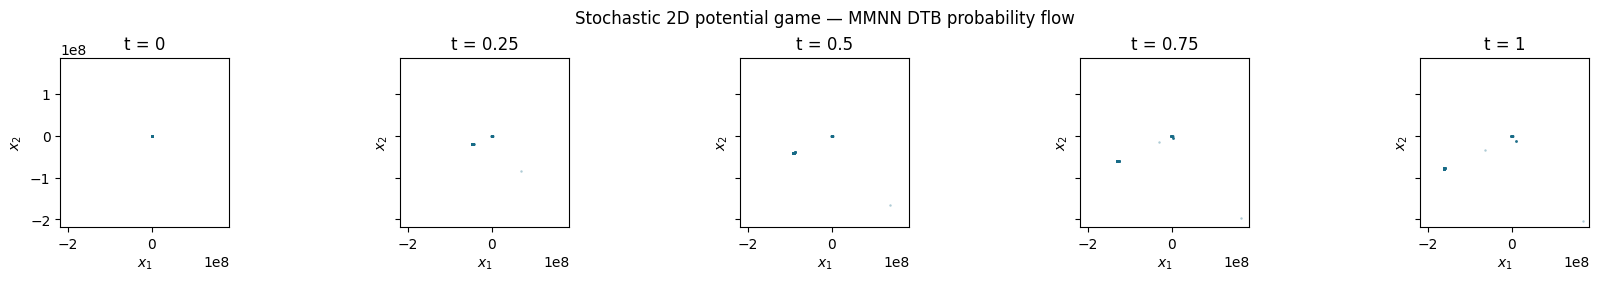

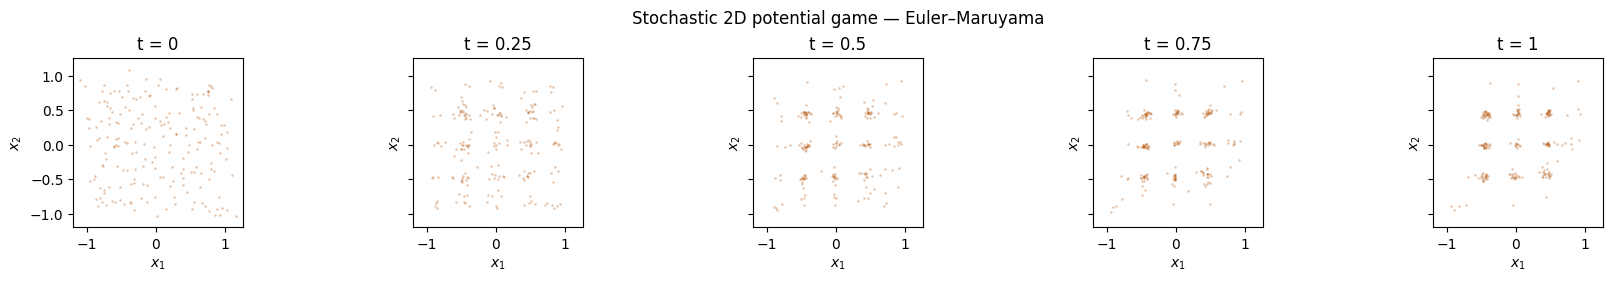

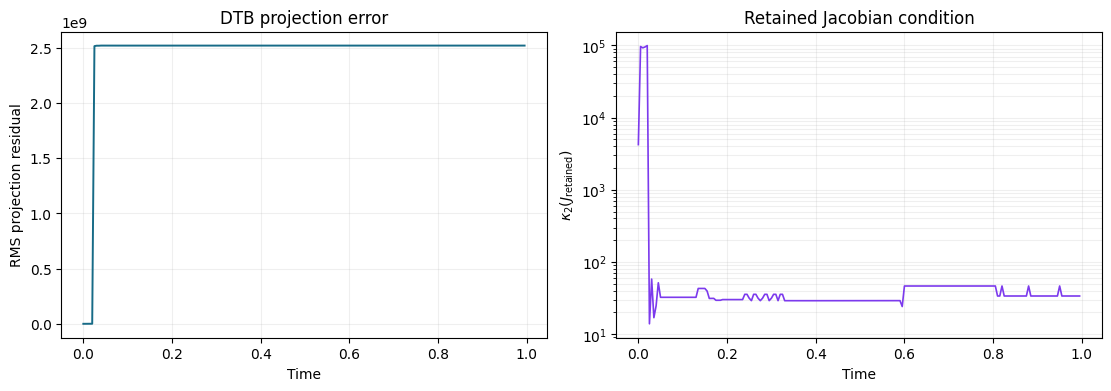

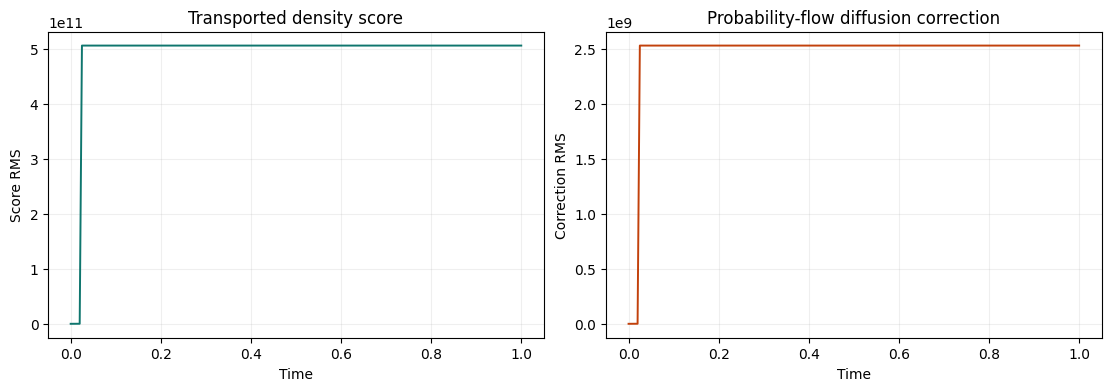

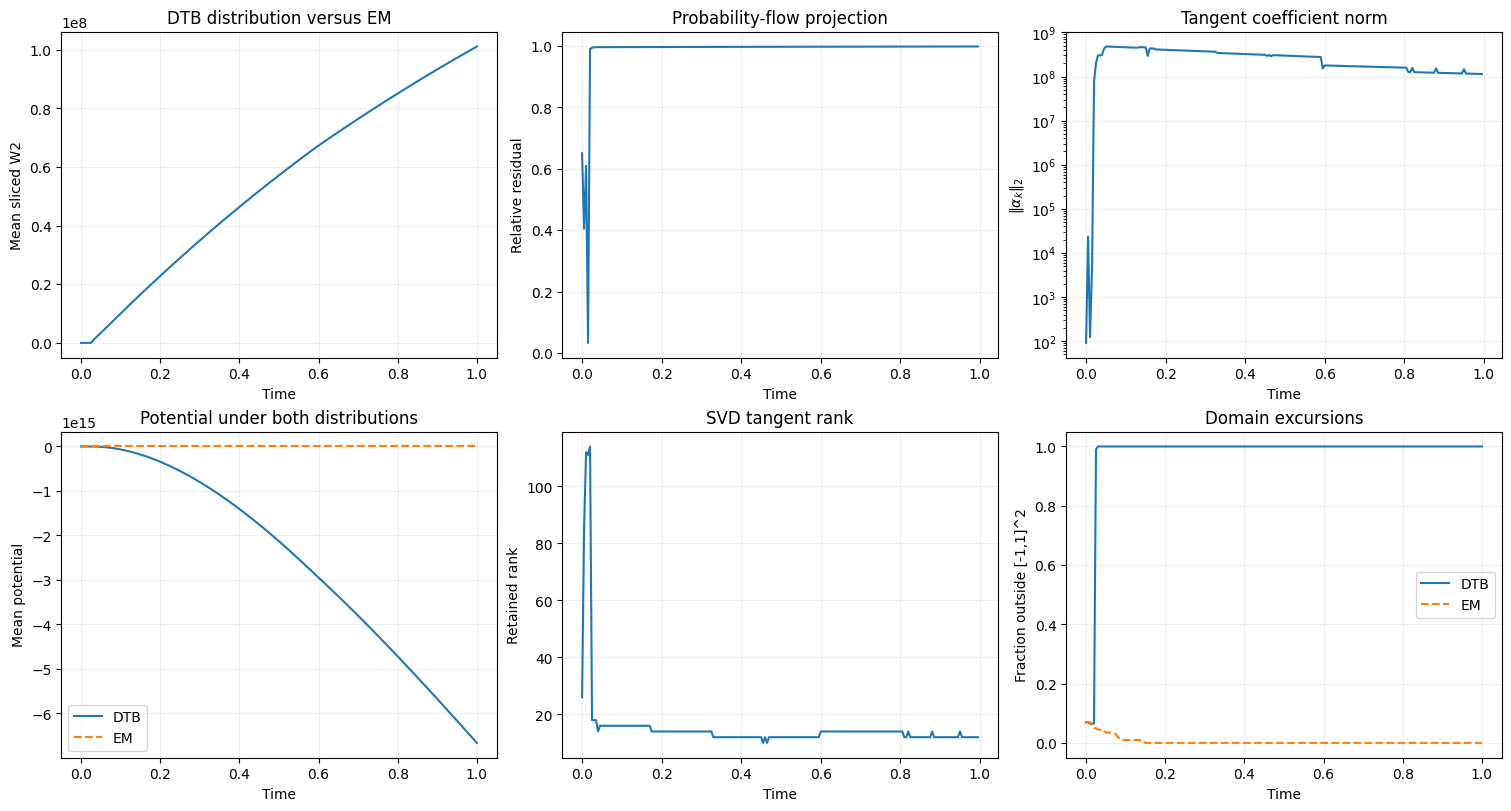

In [8]:
for snapshots, label, color, filename in (
    (dtb_snapshots, "MMNN DTB probability flow", "#176b87", "dtb_clouds.png"),
    (reference_snapshots, "Euler–Maruyama", "#b45309", "em_clouds.png"),
):
    plot_cloud_snapshots(snapshots, coordinate_pairs=[(1, 2)],
                         title=f"Stochastic 2D potential game — {label}", color=color,
                         output_path=run_dir / filename)
    plt.show()

plot_diagnostics(times[:-1], diagnostics[:, 1], diagnostics[:, 5],
                 output_path=run_dir / "projection_diagnostics.png")
plt.show()
plot_stochastic_diagnostics(times, state_diagnostics[:, 4], state_diagnostics[:, 5],
                            output_path=run_dir / "score_diagnostics.png")
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), layout="constrained")
axes[0, 0].plot(times, state_diagnostics[:, 1])
axes[0, 0].set(ylabel="Mean sliced W2", title="DTB distribution versus EM")
axes[0, 1].plot(times[:-1], diagnostics[:, 2])
axes[0, 1].set(ylabel="Relative residual", title="Probability-flow projection")
axes[0, 2].semilogy(times[:-1], np.maximum(diagnostics[:, 3], 1e-30))
axes[0, 2].set(ylabel=r"$\|\alpha_k\|_2$", title="Tangent coefficient norm")
axes[1, 0].plot(times, state_diagnostics[:, 2], label="DTB")
axes[1, 0].plot(times, state_diagnostics[:, 3], "--", label="EM")
axes[1, 0].set(ylabel="Mean potential", title="Potential under both distributions")
axes[1, 0].legend()
axes[1, 1].plot(times[:-1], diagnostics[:, 4])
axes[1, 1].set(ylabel="Retained rank", title="SVD tangent rank")
axes[1, 2].plot(times, state_diagnostics[:, 6], label="DTB")
axes[1, 2].plot(times, state_diagnostics[:, 7], "--", label="EM")
axes[1, 2].set(ylabel="Fraction outside [-1,1]^2", title="Domain excursions")
axes[1, 2].legend()
for axis in axes.flat:
    axis.set_xlabel("Time")
    axis.grid(alpha=0.2)
fig.savefig(run_dir / "stochastic_comparison.png", dpi=200, bbox_inches="tight")
plt.show()


## Archive results 

Run the final cell to create a ZIP containing the map checkpoint, numerical
arrays, configuration, and plots. In JupyterLab's file browser, navigate to the
printed directory, right-click the ZIP, and select **Download**.


In [9]:
archive = shutil.make_archive(str(run_dir), "zip", root_dir=run_dir)
print("Results folder:", run_dir)
print("Results archive:", archive)
print("Download this ZIP using the JupyterLab file browser.")


Results folder: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/potential_game_2d_stochastic_mmnn/20260921T023653_869024Z
Results archive: /storage/home/hcoda1/7/msun351/DTB_Ver3/results/potential_game_2d_stochastic_mmnn/20260921T023653_869024Z.zip
Download this ZIP using the PACE JupyterLab file browser.
